In [1]:
import pandas as pd

df = pd.read_csv("../Data/processed/carbon_emission_master.csv")

print("Dataset shape:", df.shape)

Dataset shape: (88081, 67)


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 88081 entries, 0 to 88080
Data columns (total 67 columns):
 #   Column                                                                                                                                                                                     Non-Null Count  Dtype  
---  ------                                                                                                                                                                                     --------------  -----  
 0   Facility Id                                                                                                                                                                                88081 non-null  int64  
 1   FRS Id                                                                                                                                                                                     86081 non-null  float64
 2   Facility Name                    

In [3]:
df.head()

,Facility Id,FRS Id,Facility Name,City,State,Zip Code,Address,County,Latitude,Longitude,...,Underground Coal Mines,Zinc Production,Municipal Landfills,Industrial Wastewater Treatment,Manufacture of Electric Transmission and Distribution Equipment,Industrial Waste Landfills,Is some CO2 collected on-site and used to manufacture other products and therefore not emitted from the affected manufacturing process unit(s)? (as reported under Subpart G or S),"Is some CO2 reported as emissions from the affected manufacturing process unit(s) under Subpart AA, G or P collected and transferred off-site or injected (as reported under Subpart PP)?",Does the facility employ continuous emissions monitoring?,Year
0,1004377,1.100438e+11,121 REGIONAL DISPOSAL FACILITY,MELISSA,TX,75454,3820 SAM RAYBURN HIGHWAY,COLLIN COUNTY,33.298570,-96.535860,...,NaN,NaN,194000.0,NaN,NaN,NaN,N,N,N,2011
1,1010040,1.100701e+11,15-18565/15-18662,Hazard,KY,40701,4200 S. Hwy 15,PERRY COUNTY,37.219099,-83.156046,...,390393.5,NaN,NaN,NaN,NaN,NaN,N,N,N,2011
2,1010085,1.100555e+11,15-19015,Hazard,KY,41701,1845 S. KY HWY 15,PERRY,37.236617,-83.181260,...,64664.5,NaN,NaN,NaN,NaN,NaN,N,N,N,2011
3,1000112,1.100198e+11,23rd and 3rd,BROOKLYN,NY,11232,730 3rd Avenue,Kings,40.663000,-74.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,N,N,N,2011
4,1006394,NaN,29-6 #2 Central Delivery Point,Blanco,NM,87412,NaN,Rio Arriba,36.745200,-107.445500,...,NaN,NaN,NaN,NaN,NaN,NaN,N,N,N,2011


In [4]:
df.isnull().sum()

Facility Id                                                                                                                                                                                      0
FRS Id                                                                                                                                                                                        2000
Facility Name                                                                                                                                                                                    0
City                                                                                                                                                                                             0
State                                                                                                                                                                                            0
                         

In [5]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

Silicon Carbide Production                                         88068
Adipic Acid Production                                             88048
Soda Ash Manufacturing                                             88030
HCFC–22 Production from HFC–23 Destruction                         88022
Petroleum and Natural Gas Systems – LNG Storage                    88013
Zinc Production                                                    88010
Manufacture of Electric Transmission and Distribution Equipment    88006
Titanium Dioxide Production                                        87998
Other GHGs (metric tons CO2e)                                      87977
Aluminum Production                                                87970
Petroleum and Natural Gas Systems – LNG Import/Export              87964
Miscellaneous Use of Carbonates                                    87958
Magnesium Production                                               87955
Ferroalloy Production                              

In [6]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

print(missing_percentage)

Silicon Carbide Production                                         99.985241
Adipic Acid Production                                             99.962534
Soda Ash Manufacturing                                             99.942099
HCFC–22 Production from HFC–23 Destruction                         99.933016
Petroleum and Natural Gas Systems – LNG Storage                    99.922798
Zinc Production                                                    99.919392
Manufacture of Electric Transmission and Distribution Equipment    99.914851
Titanium Dioxide Production                                        99.905769
Other GHGs (metric tons CO2e)                                      99.881927
Aluminum Production                                                99.873980
Petroleum and Natural Gas Systems – LNG Import/Export              99.867168
Miscellaneous Use of Carbonates                                    99.860356
Magnesium Production                                               99.856950

In [7]:
print(
    df.groupby("Industry Type (sectors)")[
        "Silicon Carbide Production"
    ].count().sort_values(ascending=False)
)

Industry Type (sectors)
Chemicals                                                   13
Chemicals,Coal-based Liquid Fuel Supply,Suppliers of CO2     0
Chemicals,Industrial Gas Suppliers                           0
Chemicals,Industrial Gas Suppliers,Minerals                  0
Chemicals,Industrial Gas Suppliers,Waste                     0
                                                            ..
Pulp and Paper,Suppliers of CO2,Waste                        0
Pulp and Paper,Waste                                         0
Refineries                                                   0
Refineries,Waste                                             0
Waste                                                        0
Name: Silicon Carbide Production, Length: 74, dtype: int64


In [8]:
print(
    df.groupby("Industry Type (sectors)")[
        "Stationary Combustion"
    ].count().sort_values(ascending=False)
)

Industry Type (sectors)
Petroleum and Natural Gas Systems                                                                              16135
Other                                                                                                          13287
Power Plants                                                                                                   13118
Waste                                                                                                           8255
Minerals                                                                                                        4542
                                                                                                               ...  
Natural Gas and Natural Gas Liquids Suppliers,Petroleum Product Suppliers,Petroleum and Natural Gas Systems        2
Chemicals,Other,Refineries,Suppliers of CO2                                                                        1
Chemicals,Power Plants,Suppliers of CO2 

In [9]:
print(df["Total reported direct emissions"].isnull().sum())

print(df["Total reported direct emissions"].describe())

0
count    8.808100e+04
mean     4.100934e+05
std      1.282710e+06
min     -1.196250e+03
25%      3.167448e+04
50%      6.389636e+04
75%      1.799030e+05
max      2.229333e+07
Name: Total reported direct emissions, dtype: float64


In [10]:
print(
    df.groupby("Industry Type (sectors)")[
        "Silicon Carbide Production"
    ].count().sort_values(ascending=False)
)

Industry Type (sectors)
Chemicals                                                   13
Chemicals,Coal-based Liquid Fuel Supply,Suppliers of CO2     0
Chemicals,Industrial Gas Suppliers                           0
Chemicals,Industrial Gas Suppliers,Minerals                  0
Chemicals,Industrial Gas Suppliers,Waste                     0
                                                            ..
Pulp and Paper,Suppliers of CO2,Waste                        0
Pulp and Paper,Waste                                         0
Refineries                                                   0
Refineries,Waste                                             0
Waste                                                        0
Name: Silicon Carbide Production, Length: 74, dtype: int64


In [12]:
negative_emissions = df[
    df["Total reported direct emissions"] < 0
]

print("Number of negative records:", len(negative_emissions))

negative_emissions[
    [
        "Facility Id",
        "Facility Name",
        "State",
        "Industry Type (sectors)",
        "Total reported direct emissions",
        "Year"
    ]
]

Number of negative records: 1


,Facility Id,Facility Name,State,Industry Type (sectors),Total reported direct emissions,Year
31090,1002560,"GOLDEN GRAIN ENERGY, LLC",IA,"Other,Waste",-1196.25,2015


In [13]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [14]:
print("Duplicate Facility + Year:",
      df.duplicated(
          subset=["Facility Id", "Year"]
      ).sum())

Duplicate Facility + Year: 0


In [15]:
df.dtypes

Facility Id                                                                                                                                                                                    int64
FRS Id                                                                                                                                                                                       float64
Facility Name                                                                                                                                                                                    str
City                                                                                                                                                                                             str
State                                                                                                                                                                                            str
               

In [17]:
df.select_dtypes(include="object").columns.tolist()

C:\Users\HP\AppData\Local\Temp\ipykernel_12740\3671663173.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns.tolist()


['Facility Name',
 'City',
 'State',
 'Address',
 'County',
 'Industry Type (subparts)',
 'Industry Type (sectors)',
 'Is some CO2 collected on-site and used to manufacture other products and therefore not emitted from the affected manufacturing process unit(s)? (as reported under Subpart G or S)',
 'Is some CO2 reported as emissions from the affected manufacturing process unit(s) under Subpart AA, G or P collected and transferred off-site or injected (as reported under Subpart PP)?',
 'Does the facility employ continuous emissions monitoring? ']

In [18]:
df.select_dtypes(include="number").columns.tolist()

['Facility Id',
 'FRS Id',
 'Zip Code',
 'Latitude',
 'Longitude',
 'Primary NAICS Code',
 'Total reported direct emissions',
 'CO2 emissions (non-biogenic) ',
 'Methane (CH4) emissions ',
 'Nitrous Oxide (N2O) emissions ',
 'HFC emissions',
 'PFC emissions',
 'SF6 emissions ',
 'NF3 emissions',
 'Other Fully Fluorinated GHG emissions',
 'HFE emissions',
 'Very Short-lived Compounds emissions',
 'Other GHGs (metric tons CO2e)',
 'Biogenic CO2 emissions (metric tons)',
 'Stationary Combustion',
 'Electricity Generation',
 'Adipic Acid Production',
 'Aluminum Production',
 'Ammonia Manufacturing',
 'Cement Production',
 'Electronics Manufacture',
 'Ferroalloy Production',
 'Fluorinated GHG Production',
 'Glass Production',
 'HCFC–22 Production from HFC–23 Destruction',
 'Hydrogen Production',
 'Iron and Steel Production',
 'Lead Production',
 'Lime Production',
 'Magnesium Production',
 'Miscellaneous Use of Carbonates',
 'Nitric Acid Production',
 'Petroleum and Natural Gas Systems – Of

In [19]:
categorical_columns = [
    "State",
    "Industry Type (sectors)",
    "Industry Type (subparts)",
    "Is some CO2 collected on-site and used to manufacture other products and therefore not emitted from the affected manufacturing process unit(s)? (as reported under Subpart G or S)",
    "Is some CO2 reported as emissions from the affected manufacturing process unit(s) under Subpart AA, G or P collected and transferred off-site or injected (as reported under Subpart PP)?",
    "Does the facility employ continuous emissions monitoring? "
]

for column in categorical_columns:
    print("\n" + "="*70)
    print(column)
    print("Unique values:", df[column].nunique(dropna=False))
    print(df[column].value_counts(dropna=False).head(15))


State
Unique values: 54
State
TX    10596
CA     5505
LA     5252
PA     3853
OH     3351
IL     3281
MI     2828
NY     2729
IN     2531
FL     2323
OK     2271
AL     2267
GA     2175
IA     1972
VA     1857
Name: count, dtype: int64

Industry Type (sectors)
Unique values: 74
Industry Type (sectors)
Power Plants                                                                       18245
Waste                                                                              16290
Petroleum and Natural Gas Systems                                                  16176
Other                                                                              14216
Minerals                                                                            4769
Chemicals                                                                           4386
Metals                                                                              3658
Pulp and Paper                                                           

In [20]:
numeric_df = df.select_dtypes(include="number")

print(numeric_df.describe().T)

                                                      count          mean  \
Facility Id                                         88081.0  1.005159e+06   
FRS Id                                              86081.0  1.100290e+11   
Zip Code                                            88081.0  5.414970e+04   
Latitude                                            88081.0  3.738666e+01   
Longitude                                           88081.0 -9.266254e+01   
Primary NAICS Code                                  88072.0  3.596260e+05   
Total reported direct emissions                     88081.0  4.100934e+05   
CO2 emissions (non-biogenic)                        78500.0  4.288935e+05   
Methane (CH4) emissions                             86490.0  2.204576e+04   
Nitrous Oxide (N2O) emissions                       73324.0  4.480497e+03   
HFC emissions                                         857.0  1.024902e+05   
PFC emissions                                         864.0  9.263784e+04   

In [21]:
numeric_df = df.select_dtypes(include="number")

print(numeric_df.describe().T)

                                                      count          mean  \
Facility Id                                         88081.0  1.005159e+06   
FRS Id                                              86081.0  1.100290e+11   
Zip Code                                            88081.0  5.414970e+04   
Latitude                                            88081.0  3.738666e+01   
Longitude                                           88081.0 -9.266254e+01   
Primary NAICS Code                                  88072.0  3.596260e+05   
Total reported direct emissions                     88081.0  4.100934e+05   
CO2 emissions (non-biogenic)                        78500.0  4.288935e+05   
Methane (CH4) emissions                             86490.0  2.204576e+04   
Nitrous Oxide (N2O) emissions                       73324.0  4.480497e+03   
HFC emissions                                         857.0  1.024902e+05   
PFC emissions                                         864.0  9.263784e+04   

In [22]:
non_null = df.notna().sum().sort_values()

print(non_null.head(20))

Silicon Carbide Production                                          13
Adipic Acid Production                                              33
Soda Ash Manufacturing                                              51
HCFC–22 Production from HFC–23 Destruction                          59
Petroleum and Natural Gas Systems – LNG Storage                     68
Zinc Production                                                     71
Manufacture of Electric Transmission and Distribution Equipment     75
Titanium Dioxide Production                                         83
Other GHGs (metric tons CO2e)                                      104
Aluminum Production                                                111
Petroleum and Natural Gas Systems – LNG Import/Export              117
Miscellaneous Use of Carbonates                                    123
Magnesium Production                                               126
Ferroalloy Production                                              127
Phosph

In [23]:
numeric_df = df.select_dtypes(include="number")

summary = numeric_df.describe().T

print(summary[["count", "min", "50%", "max"]])

                                                      count           min  \
Facility Id                                         88081.0  1.000001e+06   
FRS Id                                              86081.0  1.100003e+11   
Zip Code                                            88081.0  0.000000e+00   
Latitude                                            88081.0  1.329710e+01   
Longitude                                           88081.0 -1.741136e+02   
Primary NAICS Code                                  88072.0  1.114190e+05   
Total reported direct emissions                     88081.0 -1.196250e+03   
CO2 emissions (non-biogenic)                        78500.0  0.000000e+00   
Methane (CH4) emissions                             86490.0 -1.362250e+03   
Nitrous Oxide (N2O) emissions                       73324.0  1.788000e-03   
HFC emissions                                         857.0  3.375000e-01   
PFC emissions                                         864.0  8.210290e+00   

In [24]:
emission_columns = [
    "CO2 emissions (non-biogenic) ",
    "Methane (CH4) emissions ",
    "Nitrous Oxide (N2O) emissions ",
    "HFC emissions",
    "PFC emissions",
    "SF6 emissions ",
    "NF3 emissions",
    "Other Fully Fluorinated GHG emissions",
    "HFE emissions",
    "Very Short-lived Compounds emissions",
    "Other GHGs (metric tons CO2e)",
    "Biogenic CO2 emissions (metric tons)"
]

correlations = df[
    emission_columns + ["Total reported direct emissions"]
].corr()["Total reported direct emissions"].sort_values(
    ascending=False
)

print(correlations)

Total reported direct emissions          1.000000
CO2 emissions (non-biogenic)             0.994533
HFC emissions                            0.935502
Other Fully Fluorinated GHG emissions    0.615748
NF3 emissions                            0.437750
HFE emissions                            0.363449
PFC emissions                            0.337673
SF6 emissions                            0.307690
Other GHGs (metric tons CO2e)            0.245119
Nitrous Oxide (N2O) emissions            0.153189
Biogenic CO2 emissions (metric tons)     0.051631
Methane (CH4) emissions                  0.046095
Very Short-lived Compounds emissions     0.029730
Name: Total reported direct emissions, dtype: float64


In [25]:
process_columns = [
    "Stationary Combustion",
    "Electricity Generation",
    "Adipic Acid Production",
    "Aluminum Production",
    "Ammonia Manufacturing",
    "Cement Production",
    "Electronics Manufacture",
    "Ferroalloy Production",
    "Fluorinated GHG Production",
    "Glass Production",
    "Hydrogen Production",
    "Iron and Steel Production",
    "Lead Production",
    "Lime Production",
    "Magnesium Production",
    "Miscellaneous Use of Carbonates",
    "Nitric Acid Production",
    "Petrochemical Production",
    "Petroleum Refining",
    "Pulp and Paper Manufacturing",
    "Silicon Carbide Production",
    "Soda Ash Manufacturing",
    "Titanium Dioxide Production",
    "Underground Coal Mines",
    "Zinc Production",
    "Municipal Landfills",
    "Industrial Wastewater Treatment",
    "Industrial Waste Landfills"
]

process_correlations = df[
    process_columns + ["Total reported direct emissions"]
].corr()["Total reported direct emissions"].sort_values(
    ascending=False
)

print(process_correlations)

Total reported direct emissions    1.000000
Silicon Carbide Production         0.999964
Ferroalloy Production              0.999644
Electricity Generation             0.995731
Cement Production                  0.992461
Zinc Production                    0.991479
Adipic Acid Production             0.990685
Lead Production                    0.941343
Electronics Manufacture            0.935717
Titanium Dioxide Production        0.931288
Ammonia Manufacturing              0.925061
Petroleum Refining                 0.878157
Iron and Steel Production          0.863776
Glass Production                   0.853530
Magnesium Production               0.843225
Nitric Acid Production             0.708533
Fluorinated GHG Production         0.509658
Underground Coal Mines             0.481701
Pulp and Paper Manufacturing       0.476505
Municipal Landfills                0.475457
Lime Production                    0.422267
Hydrogen Production                0.411830
Stationary Combustion           

In [26]:
# Make a copy so our current dataframe remains safe
df_clean = df.copy()

# Clean column names
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[^\w]+", "_", regex=True)
    .str.strip("_")
)

# See the new column names
for i, column in enumerate(df_clean.columns):
    print(i, "→", column)

0 → facility_id
1 → frs_id
2 → facility_name
3 → city
4 → state
5 → zip_code
6 → address
7 → county
8 → latitude
9 → longitude
10 → primary_naics_code
11 → industry_type__subparts
12 → industry_type__sectors
13 → total_reported_direct_emissions
14 → co2_emissions__non_biogenic
15 → methane__ch4__emissions
16 → nitrous_oxide__n2o__emissions
17 → hfc_emissions
18 → pfc_emissions
19 → sf6_emissions
20 → nf3_emissions
21 → other_fully_fluorinated_ghg_emissions
22 → hfe_emissions
23 → very_short_lived_compounds_emissions
24 → other_ghgs__metric_tons_co2e
25 → biogenic_co2_emissions__metric_tons
26 → stationary_combustion
27 → electricity_generation
28 → adipic_acid_production
29 → aluminum_production
30 → ammonia_manufacturing
31 → cement_production
32 → electronics_manufacture
33 → ferroalloy_production
34 → fluorinated_ghg_production
35 → glass_production
36 → hcfc_22_production_from_hfc_23_destruction
37 → hydrogen_production
38 → iron_and_steel_production
39 → lead_production
40 → lime_

In [27]:
df_clean.columns.tolist()

['facility_id',
 'frs_id',
 'facility_name',
 'city',
 'state',
 'zip_code',
 'address',
 'county',
 'latitude',
 'longitude',
 'primary_naics_code',
 'industry_type__subparts',
 'industry_type__sectors',
 'total_reported_direct_emissions',
 'co2_emissions__non_biogenic',
 'methane__ch4__emissions',
 'nitrous_oxide__n2o__emissions',
 'hfc_emissions',
 'pfc_emissions',
 'sf6_emissions',
 'nf3_emissions',
 'other_fully_fluorinated_ghg_emissions',
 'hfe_emissions',
 'very_short_lived_compounds_emissions',
 'other_ghgs__metric_tons_co2e',
 'biogenic_co2_emissions__metric_tons',
 'stationary_combustion',
 'electricity_generation',
 'adipic_acid_production',
 'aluminum_production',
 'ammonia_manufacturing',
 'cement_production',
 'electronics_manufacture',
 'ferroalloy_production',
 'fluorinated_ghg_production',
 'glass_production',
 'hcfc_22_production_from_hfc_23_destruction',
 'hydrogen_production',
 'iron_and_steel_production',
 'lead_production',
 'lime_production',
 'magnesium_producti

In [28]:
# Replace multiple underscores with a single underscore
df_clean.columns = (
    df_clean.columns
    .str.replace(r"_+", "_", regex=True)
)

# Check the cleaned column names
print(df_clean.columns.tolist())

['facility_id', 'frs_id', 'facility_name', 'city', 'state', 'zip_code', 'address', 'county', 'latitude', 'longitude', 'primary_naics_code', 'industry_type_subparts', 'industry_type_sectors', 'total_reported_direct_emissions', 'co2_emissions_non_biogenic', 'methane_ch4_emissions', 'nitrous_oxide_n2o_emissions', 'hfc_emissions', 'pfc_emissions', 'sf6_emissions', 'nf3_emissions', 'other_fully_fluorinated_ghg_emissions', 'hfe_emissions', 'very_short_lived_compounds_emissions', 'other_ghgs_metric_tons_co2e', 'biogenic_co2_emissions_metric_tons', 'stationary_combustion', 'electricity_generation', 'adipic_acid_production', 'aluminum_production', 'ammonia_manufacturing', 'cement_production', 'electronics_manufacture', 'ferroalloy_production', 'fluorinated_ghg_production', 'glass_production', 'hcfc_22_production_from_hfc_23_destruction', 'hydrogen_production', 'iron_and_steel_production', 'lead_production', 'lime_production', 'magnesium_production', 'miscellaneous_use_of_carbonates', 'nitric_ac

In [29]:
print(df_clean.shape)

(88081, 67)


In [30]:
# Count missing values in each column
missing = df_clean.isnull().sum()

# Show only columns that have missing values
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

silicon_carbide_production                                         88068
adipic_acid_production                                             88048
soda_ash_manufacturing                                             88030
hcfc_22_production_from_hfc_23_destruction                         88022
petroleum_and_natural_gas_systems_lng_storage                      88013
zinc_production                                                    88010
manufacture_of_electric_transmission_and_distribution_equipment    88006
titanium_dioxide_production                                        87998
other_ghgs_metric_tons_co2e                                        87977
aluminum_production                                                87970
petroleum_and_natural_gas_systems_lng_import_export                87964
miscellaneous_use_of_carbonates                                    87958
magnesium_production                                               87955
ferroalloy_production                              

In [31]:
# Missing percentage
missing_percentage = (df_clean.isnull().sum() / len(df_clean)) * 100

missing_percentage = (
    missing_percentage[missing_percentage > 0]
    .sort_values(ascending=False)
)

print(missing_percentage)

silicon_carbide_production                                         99.985241
adipic_acid_production                                             99.962534
soda_ash_manufacturing                                             99.942099
hcfc_22_production_from_hfc_23_destruction                         99.933016
petroleum_and_natural_gas_systems_lng_storage                      99.922798
zinc_production                                                    99.919392
manufacture_of_electric_transmission_and_distribution_equipment    99.914851
titanium_dioxide_production                                        99.905769
other_ghgs_metric_tons_co2e                                        99.881927
aluminum_production                                                99.873980
petroleum_and_natural_gas_systems_lng_import_export                99.867168
miscellaneous_use_of_carbonates                                    99.860356
magnesium_production                                               99.856950

In [32]:
categorical_columns = [
    "facility_name",
    "city",
    "state",
    "address",
    "county",
    "industry_type_subparts",
    "industry_type_sectors"
]

In [33]:
id_columns = [
    "facility_id",
    "frs_id",
    "facility_name",
    "address"
]

In [34]:
target = "total_reported_direct_emissions"

In [35]:
process_columns = [
    "stationary_combustion",
    "electricity_generation",
    "adipic_acid_production",
    "aluminum_production",
    "ammonia_manufacturing",
    "cement_production",
    "electronics_manufacture",
    "ferroalloy_production",
    "fluorinated_ghg_production",
    "glass_production",
    "hcfc_22_production_from_hfc_23_destruction",
    "hydrogen_production",
    "iron_and_steel_production",
    "lead_production",
    "lime_production",
    "magnesium_production",
    "miscellaneous_use_of_carbonates",
    "nitric_acid_production",
    "petroleum_and_natural_gas_systems_offshore_production",
    "petroleum_and_natural_gas_systems_processing",
    "petroleum_and_natural_gas_systems_transmission_compression",
    "petroleum_and_natural_gas_systems_underground_storage",
    "petroleum_and_natural_gas_systems_lng_storage",
    "petroleum_and_natural_gas_systems_lng_import_export",
    "petrochemical_production",
    "petroleum_refining",
    "phosphoric_acid_production",
    "pulp_and_paper_manufacturing",
    "silicon_carbide_production",
    "soda_ash_manufacturing",
    "titanium_dioxide_production",
    "underground_coal_mines",
    "zinc_production",
    "municipal_landfills",
    "industrial_wastewater_treatment",
    "manufacture_of_electric_transmission_and_distribution_equipment",
    "industrial_waste_landfills"
]

for col in process_columns:
    print(
        col,
        "| Missing:", df_clean[col].isna().sum(),
        "| Zero:", (df_clean[col] == 0).sum(),
        "| Non-zero:", (df_clean[col] > 0).sum()
    )

stationary_combustion | Missing: 15019 | Zero: 1064 | Non-zero: 71998
electricity_generation | Missing: 72818 | Zero: 288 | Non-zero: 14975
adipic_acid_production | Missing: 88048 | Zero: 2 | Non-zero: 31
aluminum_production | Missing: 87970 | Zero: 12 | Non-zero: 99
ammonia_manufacturing | Missing: 87739 | Zero: 1 | Non-zero: 341
cement_production | Missing: 86859 | Zero: 24 | Non-zero: 1198
electronics_manufacture | Missing: 87405 | Zero: 2 | Non-zero: 674
ferroalloy_production | Missing: 87954 | Zero: 0 | Non-zero: 127
fluorinated_ghg_production | Missing: 87886 | Zero: 0 | Non-zero: 195
glass_production | Missing: 86718 | Zero: 25 | Non-zero: 1338
hcfc_22_production_from_hfc_23_destruction | Missing: 88022 | Zero: 8 | Non-zero: 51
hydrogen_production | Missing: 86630 | Zero: 38 | Non-zero: 1413
iron_and_steel_production | Missing: 86464 | Zero: 21 | Non-zero: 1596
lead_production | Missing: 87928 | Zero: 11 | Non-zero: 142
lime_production | Missing: 87134 | Zero: 5 | Non-zero: 942


In [36]:
df[df["total_reported_direct_emissions"] < 0][
    ["facility_id", "facility_name", "state",
     "total_reported_direct_emissions", "year"]
]

KeyError: 'total_reported_direct_emissions'

In [37]:
print(df.columns.tolist())

['Facility Id', 'FRS Id', 'Facility Name', 'City', 'State', 'Zip Code', 'Address', 'County', 'Latitude', 'Longitude', 'Primary NAICS Code', 'Industry Type (subparts)', 'Industry Type (sectors)', 'Total reported direct emissions', 'CO2 emissions (non-biogenic) ', 'Methane (CH4) emissions ', 'Nitrous Oxide (N2O) emissions ', 'HFC emissions', 'PFC emissions', 'SF6 emissions ', 'NF3 emissions', 'Other Fully Fluorinated GHG emissions', 'HFE emissions', 'Very Short-lived Compounds emissions', 'Other GHGs (metric tons CO2e)', 'Biogenic CO2 emissions (metric tons)', 'Stationary Combustion', 'Electricity Generation', 'Adipic Acid Production', 'Aluminum Production', 'Ammonia Manufacturing', 'Cement Production', 'Electronics Manufacture', 'Ferroalloy Production', 'Fluorinated GHG Production', 'Glass Production', 'HCFC–22 Production from HFC–23 Destruction', 'Hydrogen Production', 'Iron and Steel Production', 'Lead Production', 'Lime Production', 'Magnesium Production', 'Miscellaneous Use of Carbo

In [38]:
df[df["Total reported direct emissions"] < 0][
    ["Facility Id", "Facility Name", "State",
     "Total reported direct emissions", "Year"]
]

,Facility Id,Facility Name,State,Total reported direct emissions,Year
31090,1002560,"GOLDEN GRAIN ENERGY, LLC",IA,-1196.25,2015


In [39]:
print(df.columns.tolist())

['Facility Id', 'FRS Id', 'Facility Name', 'City', 'State', 'Zip Code', 'Address', 'County', 'Latitude', 'Longitude', 'Primary NAICS Code', 'Industry Type (subparts)', 'Industry Type (sectors)', 'Total reported direct emissions', 'CO2 emissions (non-biogenic) ', 'Methane (CH4) emissions ', 'Nitrous Oxide (N2O) emissions ', 'HFC emissions', 'PFC emissions', 'SF6 emissions ', 'NF3 emissions', 'Other Fully Fluorinated GHG emissions', 'HFE emissions', 'Very Short-lived Compounds emissions', 'Other GHGs (metric tons CO2e)', 'Biogenic CO2 emissions (metric tons)', 'Stationary Combustion', 'Electricity Generation', 'Adipic Acid Production', 'Aluminum Production', 'Ammonia Manufacturing', 'Cement Production', 'Electronics Manufacture', 'Ferroalloy Production', 'Fluorinated GHG Production', 'Glass Production', 'HCFC–22 Production from HFC–23 Destruction', 'Hydrogen Production', 'Iron and Steel Production', 'Lead Production', 'Lime Production', 'Magnesium Production', 'Miscellaneous Use of Carbo

In [40]:
negative_emissions = df[df["Total reported direct emissions"] < 0]

negative_emissions[
    ["Facility Id", "Facility Name", "State",
     "Total reported direct emissions", "Year"]
]

,Facility Id,Facility Name,State,Total reported direct emissions,Year
31090,1002560,"GOLDEN GRAIN ENERGY, LLC",IA,-1196.25,2015


In [41]:
print("Negative emissions:", (df["Total reported direct emissions"] < 0).sum())

Negative emissions: 1


In [42]:
# Check completely duplicated rows
print("Duplicate rows:", df.duplicated().sum())

# Check duplicate Facility + Year combinations
print("Duplicate Facility + Year:",
      df.duplicated(subset=["Facility Id", "Year"]).sum())

Duplicate rows: 0
Duplicate Facility + Year: 0


In [43]:
# Numeric columns
numeric_cols = df.select_dtypes(include="number").columns.tolist()

print("Numeric columns:")
print(numeric_cols)

Numeric columns:
['Facility Id', 'FRS Id', 'Zip Code', 'Latitude', 'Longitude', 'Primary NAICS Code', 'Total reported direct emissions', 'CO2 emissions (non-biogenic) ', 'Methane (CH4) emissions ', 'Nitrous Oxide (N2O) emissions ', 'HFC emissions', 'PFC emissions', 'SF6 emissions ', 'NF3 emissions', 'Other Fully Fluorinated GHG emissions', 'HFE emissions', 'Very Short-lived Compounds emissions', 'Other GHGs (metric tons CO2e)', 'Biogenic CO2 emissions (metric tons)', 'Stationary Combustion', 'Electricity Generation', 'Adipic Acid Production', 'Aluminum Production', 'Ammonia Manufacturing', 'Cement Production', 'Electronics Manufacture', 'Ferroalloy Production', 'Fluorinated GHG Production', 'Glass Production', 'HCFC–22 Production from HFC–23 Destruction', 'Hydrogen Production', 'Iron and Steel Production', 'Lead Production', 'Lime Production', 'Magnesium Production', 'Miscellaneous Use of Carbonates', 'Nitric Acid Production', 'Petroleum and Natural Gas Systems – Offshore Production', 

In [44]:
# Categorical/text columns
categorical_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

Categorical columns:
['Facility Name', 'City', 'State', 'Address', 'County', 'Industry Type (subparts)', 'Industry Type (sectors)', 'Is some CO2 collected on-site and used to manufacture other products and therefore not emitted from the affected manufacturing process unit(s)? (as reported under Subpart G or S)', 'Is some CO2 reported as emissions from the affected manufacturing process unit(s) under Subpart AA, G or P collected and transferred off-site or injected (as reported under Subpart PP)?', 'Does the facility employ continuous emissions monitoring? ']


In [45]:
# Show missing percentage for numeric columns
missing_numeric = (
    df[numeric_cols]
    .isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(missing_numeric)

Silicon Carbide Production                                         99.985241
Adipic Acid Production                                             99.962534
Soda Ash Manufacturing                                             99.942099
HCFC–22 Production from HFC–23 Destruction                         99.933016
Petroleum and Natural Gas Systems – LNG Storage                    99.922798
Zinc Production                                                    99.919392
Manufacture of Electric Transmission and Distribution Equipment    99.914851
Titanium Dioxide Production                                        99.905769
Other GHGs (metric tons CO2e)                                      99.881927
Aluminum Production                                                99.873980
Petroleum and Natural Gas Systems – LNG Import/Export              99.867168
Miscellaneous Use of Carbonates                                    99.860356
Magnesium Production                                               99.856950

In [46]:
# Show numeric columns with less than 50% missing values
print(
    missing_numeric[missing_numeric < 50]
)

Stationary Combustion              17.051350
Nitrous Oxide (N2O) emissions      16.753897
CO2 emissions (non-biogenic)       10.877488
FRS Id                              2.270637
Methane (CH4) emissions             1.806292
Primary NAICS Code                  0.010218
Longitude                           0.000000
Facility Id                         0.000000
Total reported direct emissions     0.000000
Latitude                            0.000000
Zip Code                            0.000000
Year                                0.000000
dtype: float64


In [47]:
# Check the relationship between the main emission variables
main_emission_cols = [
    "Total reported direct emissions",
    "CO2 emissions (non-biogenic) ",
    "Methane (CH4) emissions ",
    "Nitrous Oxide (N2O) emissions ",
    "Biogenic CO2 emissions (metric tons)",
    "Stationary Combustion",
    "Electricity Generation"
]

print(df[main_emission_cols].corr()["Total reported direct emissions"].sort_values(ascending=False))

Total reported direct emissions         1.000000
Electricity Generation                  0.995731
CO2 emissions (non-biogenic)            0.994533
Stationary Combustion                   0.337952
Nitrous Oxide (N2O) emissions           0.153189
Biogenic CO2 emissions (metric tons)    0.051631
Methane (CH4) emissions                 0.046095
Name: Total reported direct emissions, dtype: float64


In [48]:
print(df["Total reported direct emissions"].describe())

count    8.808100e+04
mean     4.100934e+05
std      1.282710e+06
min     -1.196250e+03
25%      3.167448e+04
50%      6.389636e+04
75%      1.799030e+05
max      2.229333e+07
Name: Total reported direct emissions, dtype: float64


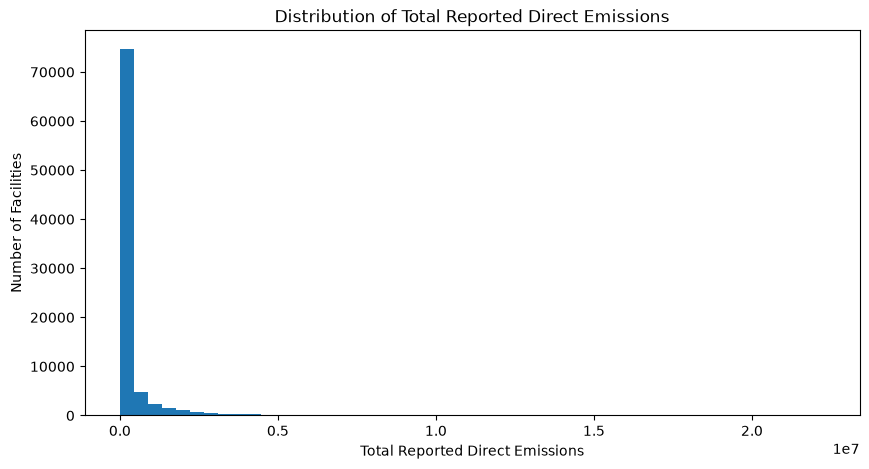

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(df["Total reported direct emissions"], bins=50)
plt.xlabel("Total Reported Direct Emissions")
plt.ylabel("Number of Facilities")
plt.title("Distribution of Total Reported Direct Emissions")
plt.show()

In [50]:
# Create a copy of the target
df["target_emissions"] = df["Total reported direct emissions"]

# Identify negative target values
negative_mask = df["target_emissions"] < 0

print("Negative target values:", negative_mask.sum())
print(df.loc[negative_mask, [
    "Facility Id",
    "Facility Name",
    "State",
    "target_emissions",
    "Year"
]])

Negative target values: 1
       Facility Id             Facility Name State  target_emissions  Year
31090      1002560  GOLDEN GRAIN ENERGY, LLC    IA          -1196.25  2015


In [51]:
# Remove the negative target observation from the modeling dataset
df_model = df[~negative_mask].copy()

print("Original rows:", len(df))
print("Modeling rows:", len(df_model))
print("Removed rows:", len(df) - len(df_model))

Original rows: 88081
Modeling rows: 88080
Removed rows: 1


In [52]:
df["target_emissions"] = df["Total reported direct emissions"]

negative_mask = df["target_emissions"] < 0

print("Negative target values:", negative_mask.sum())

print(df.loc[negative_mask, [
    "Facility Id",
    "Facility Name",
    "State",
    "target_emissions",
    "Year"
]])

Negative target values: 1
       Facility Id             Facility Name State  target_emissions  Year
31090      1002560  GOLDEN GRAIN ENERGY, LLC    IA          -1196.25  2015


In [53]:
df_model = df[~negative_mask].copy()

print("Original rows:", len(df))
print("Modeling rows:", len(df_model))
print("Removed rows:", len(df) - len(df_model))

Original rows: 88081
Modeling rows: 88080
Removed rows: 1


In [54]:
missing_model = (
    df_model.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_model = missing_model[missing_model > 0]

print(missing_model)

Silicon Carbide Production                                         88067
Adipic Acid Production                                             88047
Soda Ash Manufacturing                                             88029
HCFC–22 Production from HFC–23 Destruction                         88021
Petroleum and Natural Gas Systems – LNG Storage                    88012
Zinc Production                                                    88009
Manufacture of Electric Transmission and Distribution Equipment    88005
Titanium Dioxide Production                                        87997
Other GHGs (metric tons CO2e)                                      87976
Aluminum Production                                                87969
Petroleum and Natural Gas Systems – LNG Import/Export              87963
Miscellaneous Use of Carbonates                                    87957
Magnesium Production                                               87954
Ferroalloy Production                              

In [55]:
missing_percentage_model = (
    df_model.isnull().mean() * 100
).sort_values(ascending=False)

missing_percentage_model = missing_percentage_model[
    missing_percentage_model > 0
]

print(missing_percentage_model)

Silicon Carbide Production                                         99.985241
Adipic Acid Production                                             99.962534
Soda Ash Manufacturing                                             99.942098
HCFC–22 Production from HFC–23 Destruction                         99.933015
Petroleum and Natural Gas Systems – LNG Storage                    99.922797
Zinc Production                                                    99.919391
Manufacture of Electric Transmission and Distribution Equipment    99.914850
Titanium Dioxide Production                                        99.905767
Other GHGs (metric tons CO2e)                                      99.881926
Aluminum Production                                                99.873978
Petroleum and Natural Gas Systems – LNG Import/Export              99.867166
Miscellaneous Use of Carbonates                                    99.860354
Magnesium Production                                               99.856948

In [56]:
# Save cleaned dataset
df_model.to_csv("cleaned_emissions_data.csv", index=False)

print("Cleaned dataset saved successfully.")
print("Shape:", df_model.shape)

Cleaned dataset saved successfully.
Shape: (88080, 68)
